##### Import Root & Opening Files

In [2]:
import ROOT

ROOT.gStyle.SetOptStat(0)

ggF_f = ROOT.TFile("PPSSP_2026/1l2tau/run2/signal_ggF.root") # Gluon-Gluon Fusion
VBF_f = ROOT.TFile("PPSSP_2026/1l2tau/run2/signal_VBF.root") # Vector Boson Fusion


ggF_f.ls()
VBF_f.ls()

TFile**		PPSSP_2026/1l2tau/run2/signal_ggF.root	
 TFile*		PPSSP_2026/1l2tau/run2/signal_ggF.root	
  KEY: TTree	AnalysisMiniTree;1	AnalysisMiniTree
TFile**		PPSSP_2026/1l2tau/run2/signal_VBF.root	
 TFile*		PPSSP_2026/1l2tau/run2/signal_VBF.root	
  KEY: TTree	AnalysisMiniTree;1	AnalysisMiniTree


/home/est3ban3/IFJ_PAN_PROJECT/MVA-Project/venv/lib/python3.14/site-packages/ROOT/__init__.py:222: UserWarning: 
This distribution of ROOT is in alpha stage. Feedback is welcome and appreciated. Feel free to reach out to the user forum for questions and general feedback at https://root-forum.cern.ch or to submit an issue at https://github.com/root-project/root/issues. Do not rely on this distribution for production purposes.

  warnings.warn(


In [8]:
ggF_tree = ggF_f.Get("AnalysisMiniTree")
ggF_tree.Print()

******************************************************************************
*Tree    :AnalysisMiniTree: AnalysisMiniTree                                       *
*Entries :   133971 : Total =        71251418 bytes  File  Size =   32164787 *
*        :          : Tree compression factor =   2.21                       *
******************************************************************************
*Br    0 :dsid      : dsid/I                                                 *
*Entries :   133971 : Total  Size=     539584 bytes  File Size  =       6445 *
*Baskets :       33 : Basket Size=      32000 bytes  Compression=  83.57     *
*............................................................................*
*Br    1 :hhml_subChannelFlavor : hhml_subChannelFlavor/I                    *
*Entries :   133971 : Total  Size=     540213 bytes  File Size  =      58665 *
*Baskets :       33 : Basket Size=      32000 bytes  Compression=   9.19     *
*.............................................

In [12]:
VBF_tree = VBF_f.Get("AnalysisMiniTree")
VBF_tree.Print()

******************************************************************************
*Tree    :AnalysisMiniTree: AnalysisMiniTree                                       *
*Entries :    47257 : Total =        25293543 bytes  File  Size =   11338054 *
*        :          : Tree compression factor =   2.23                       *
******************************************************************************
*Br    0 :dsid      : dsid/I                                                 *
*Entries :    47257 : Total  Size=     191492 bytes  File Size  =       3295 *
*Baskets :       21 : Basket Size=      32000 bytes  Compression=  57.90     *
*............................................................................*
*Br    1 :hhml_subChannelFlavor : hhml_subChannelFlavor/I                    *
*Entries :    47257 : Total  Size=     191917 bytes  File Size  =      21920 *
*Baskets :       21 : Basket Size=      32000 bytes  Compression=   8.72     *
*.............................................

### Combining both Signals

In [3]:
sig_chain = ROOT.TChain("AnalysisMiniTree")
sig_chain.Add("PPSSP_2026/1l2tau/run2/signal_ggF.root")
sig_chain.Add("PPSSP_2026/1l2tau/run2/signal_VBF.root")

1

## VGamma Background

### Met-Met Branch

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c_met_vgamma
Info in <TCanvas::Print>: png file met_sig_vs_vgamma.png has been created


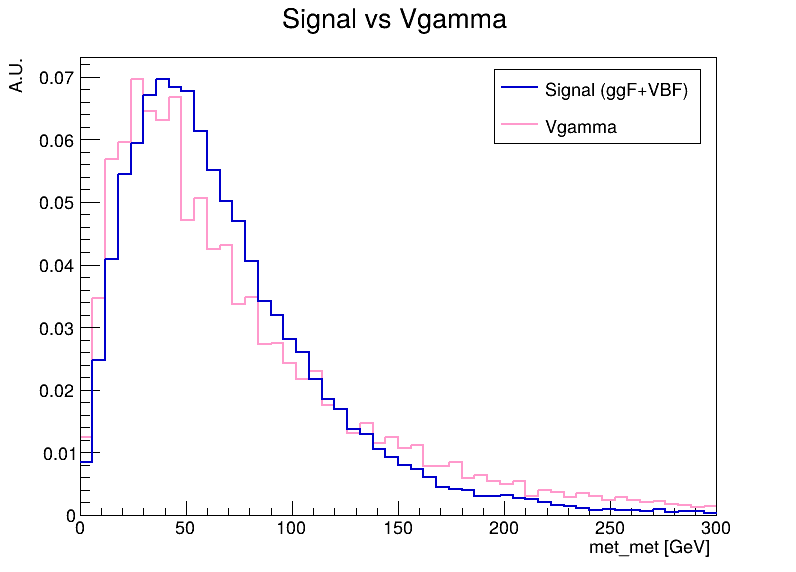

In [10]:
# Open Vgamma background
f_vgamma = ROOT.TFile("PPSSP_2026/1l2tau/run2/Vgamma.root")
t_vgamma = f_vgamma.Get("AnalysisMiniTree")

# Build dataframes
df_sig = ROOT.RDataFrame(sig_chain)
df_bkg = ROOT.RDataFrame(t_vgamma)

# Apply baseline selection
selection = "n_b_jet == 0 && n_jet >= 2"

df_sig = df_sig.Filter(selection)
df_bkg = df_bkg.Filter(selection)

# Convert met_met from MeV to GeV
df_sig = df_sig.Define("met_met_GeV", "met_met / 1000.")
df_bkg = df_bkg.Define("met_met_GeV", "met_met / 1000.")

# Build weighted histograms
h_sig_ptr = df_sig.Histo1D(("h_sig", "Signal vs Vgamma;met_met [GeV];A.U.", 50, 0, 300), "met_met_GeV", "weight")
h_bkg_ptr = df_bkg.Histo1D(("h_bkg", "Signal vs Vgamma;met_met [GeV];A.U.", 50, 0, 300), "met_met_GeV", "weight")

# Materialize lazy RDataFrame histograms
h_sig = h_sig_ptr.GetValue()
h_bkg = h_bkg_ptr.GetValue()

# Normalize to unit area for shape comparison
if h_sig.Integral() > 0:
    h_sig.Scale(1.0 / h_sig.Integral())
if h_bkg.Integral() > 0:
    h_bkg.Scale(1.0 / h_bkg.Integral())

# Draw and save
c = ROOT.TCanvas("c_met_vgamma", "met_met signal vs Vgamma", 800, 600)
h_bkg.SetLineColor(ROOT.kPink + 1)
h_bkg.SetLineWidth(2)
h_sig.SetLineColor(ROOT.kBlue + 1)
h_sig.SetLineWidth(2)
h_bkg.Draw("hist")
h_sig.Draw("hist same")

leg = ROOT.TLegend(0.62, 0.75, 0.88, 0.88)
leg.AddEntry(h_sig, "Signal (ggF+VBF)", "l")
leg.AddEntry(h_bkg, "Vgamma", "l")
leg.Draw()

c.SaveAs("met_sig_vs_vgamma.png")
c.Draw()

## VVV Jets 

### Met-Met

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c_met_vvv
Info in <TCanvas::Print>: png file met_sig_vs_vvv.png has been created


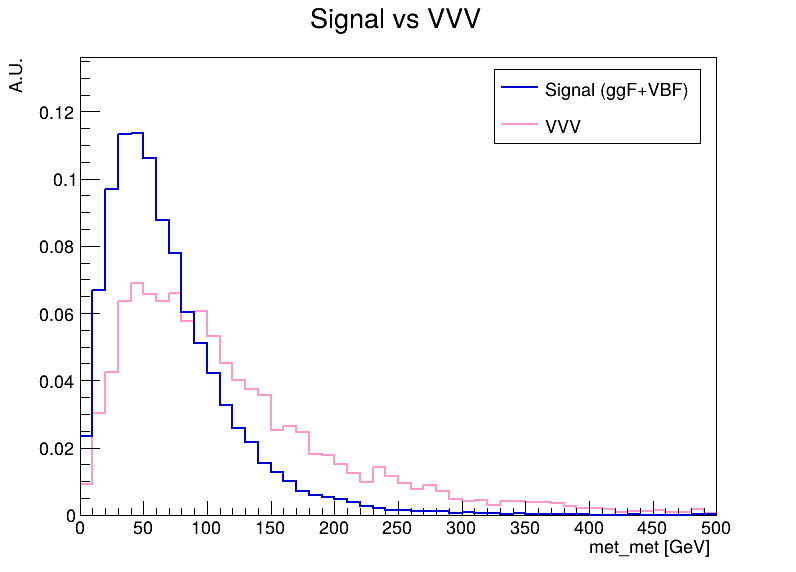

In [18]:
# Open VVV background
f_vvv = ROOT.TFile("PPSSP_2026/1l2tau/run2/VVV.root")
t_vvv = f_vvv.Get("AnalysisMiniTree")

# Build dataframes
df_sig_vvv = ROOT.RDataFrame(sig_chain)
df_bkg_vvv = ROOT.RDataFrame(t_vvv)

# Apply baseline selection
df_sig_vvv = df_sig_vvv.Filter(selection)
df_bkg_vvv = df_bkg_vvv.Filter(selection)

# Convert met_met from MeV to GeV
df_sig_vvv = df_sig_vvv.Define("met_met_GeV", "met_met / 1000.")
df_bkg_vvv = df_bkg_vvv.Define("met_met_GeV", "met_met / 1000.")

# Build weighted histograms
h_sig_vvv_ptr = df_sig_vvv.Histo1D(("h_sig_vvv", "Signal vs VVV;met_met [GeV];A.U.", 50, 0, 500), "met_met_GeV", "weight")
h_bkg_vvv_ptr = df_bkg_vvv.Histo1D(("h_bkg_vvv", "Signal vs VVV;met_met [GeV];A.U.", 50, 0, 500), "met_met_GeV", "weight")

# Materialize lazy RDataFrame histograms
h_sig_vvv = h_sig_vvv_ptr.GetValue()
h_bkg_vvv = h_bkg_vvv_ptr.GetValue()

# Normalize to unit area for shape comparison
if h_sig_vvv.Integral() > 0:
    h_sig_vvv.Scale(1.0 / h_sig_vvv.Integral())
if h_bkg_vvv.Integral() > 0:
    h_bkg_vvv.Scale(1.0 / h_bkg_vvv.Integral())

# Set y-axis maximum with 20% headroom
ymax = max(h_sig_vvv.GetMaximum(), h_bkg_vvv.GetMaximum()) * 1.2
h_bkg_vvv.SetMaximum(ymax)

# Draw and save
c_vvv = ROOT.TCanvas("c_met_vvv", "met_met signal vs VVV", 800, 600)
h_bkg_vvv.SetLineColor(ROOT.kPink + 1)
h_bkg_vvv.SetLineWidth(2)
h_sig_vvv.SetLineColor(ROOT.kBlue + 1)
h_sig_vvv.SetLineWidth(2)
h_bkg_vvv.Draw("hist")
h_sig_vvv.Draw("hist same")

leg_vvv = ROOT.TLegend(0.62, 0.75, 0.88, 0.88)
leg_vvv.AddEntry(h_sig_vvv, "Signal (ggF+VBF)", "l")
leg_vvv.AddEntry(h_bkg_vvv, "VVV", "l")
leg_vvv.Draw()

c_vvv.SaveAs("met_sig_vs_vvv.png")
c_vvv.Draw()

## W Jets

### Met-Met Branch

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c_met_wjets
Info in <TCanvas::Print>: png file met_sig_vs_wjets.png has been created


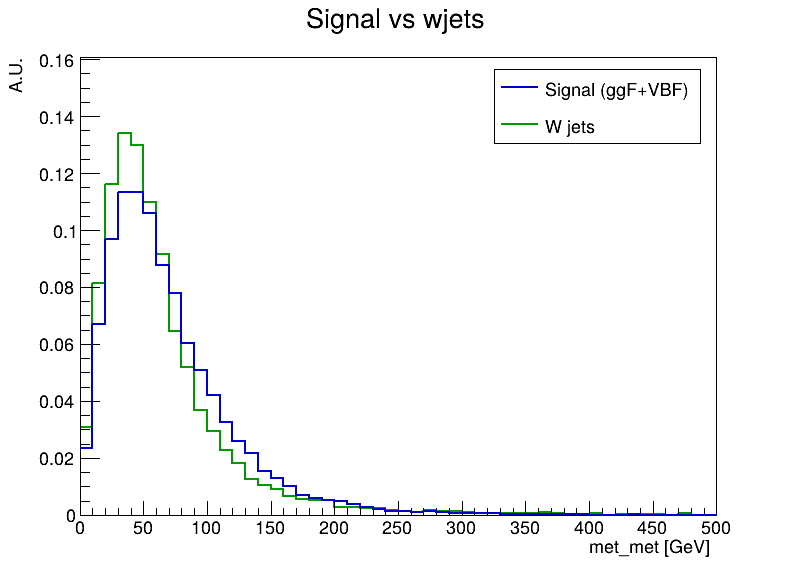

In [ ]:
# Open wjets background
f_wjets = ROOT.TFile("PPSSP_2026/1l2tau/run2/Wjets.root")
t_wjets = f_wjets.Get("AnalysisMiniTree")

# Build dataframes
df_sig_wjets = ROOT.RDataFrame(sig_chain)
df_bkg_wjets = ROOT.RDataFrame(t_wjets)

# Apply baseline selection
df_sig_wjets = df_sig_wjets.Filter(selection)
df_bkg_wjets = df_bkg_wjets.Filter(selection)

# Convert met_met from MeV to GeV
df_sig_wjets = df_sig_wjets.Define("met_met_GeV", "met_met / 1000.")
df_bkg_wjets = df_bkg_wjets.Define("met_met_GeV", "met_met / 1000.")

# Build weighted histograms
h_sig_wjets_ptr = df_sig_wjets.Histo1D(("h_sig_wjets", "Signal vs wjets;met_met [GeV];A.U.", 50, 0, 500), "met_met_GeV", "weight")
h_bkg_wjets_ptr = df_bkg_wjets.Histo1D(("h_bkg_wjets", "Signal vs wjets;met_met [GeV];A.U.", 50, 0, 500), "met_met_GeV", "weight")

# Materialize lazy RDataFrame histograms
h_sig_wjets = h_sig_wjets_ptr.GetValue()
h_bkg_wjets = h_bkg_wjets_ptr.GetValue()

# Normalize to unit area for shape comparison
if h_sig_wjets.Integral() > 0:
    h_sig_wjets.Scale(1.0 / h_sig_wjets.Integral())
if h_bkg_wjets.Integral() > 0:
    h_bkg_wjets.Scale(1.0 / h_bkg_wjets.Integral())

# Set y-axis maximum with 20% headroom
ymax = max(h_sig_wjets.GetMaximum(), h_bkg_wjets.GetMaximum()) * 1.2
h_bkg_wjets.SetMaximum(ymax)

# Draw and save
c_wjets = ROOT.TCanvas("c_met_wjets", "met_met signal vs wjets", 800, 600)
h_bkg_wjets.SetLineColor(ROOT.kPink + 2)
h_bkg_wjets.SetLineWidth(2)
h_sig_wjets.SetLineColor(ROOT.kBlue + 1)
h_sig_wjets.SetLineWidth(2)
h_bkg_wjets.Draw("hist")
h_sig_wjets.Draw("hist same")

leg_wjets = ROOT.TLegend(0.62, 0.75, 0.88, 0.88)
leg_wjets.AddEntry(h_sig_wjets, "Signal (ggF+VBF)", "l")
leg_wjets.AddEntry(h_bkg_wjets, "W jets", "l")
leg_wjets.Draw()

c_wjets.SaveAs("met_sig_vs_wjets.png")
c_wjets.Draw()

Info in <TCanvas::Print>: png file met_sig_vs_zjets.png has been created


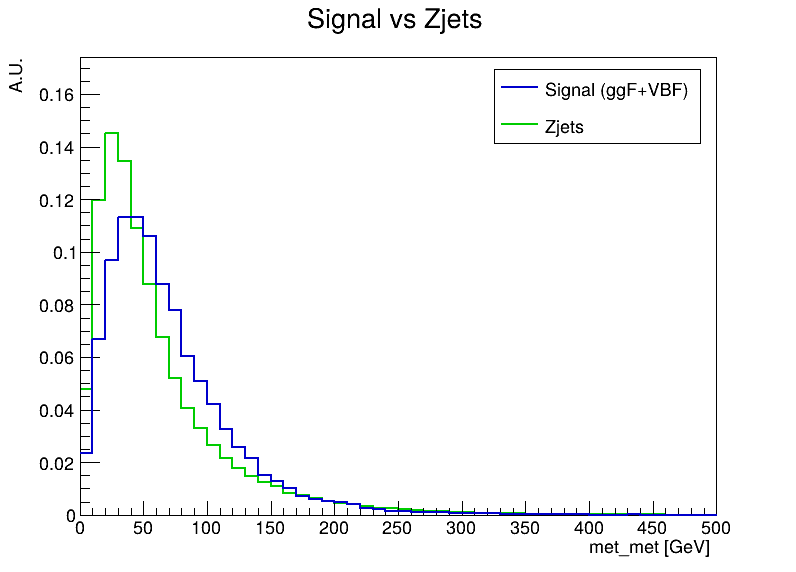

In [17]:
# Open Zjets background
f_zjets = ROOT.TFile("PPSSP_2026/1l2tau/run2/Zjets.root")
t_zjets = f_zjets.Get("AnalysisMiniTree")

# Build dataframes
df_sig_zjets = ROOT.RDataFrame(sig_chain)
df_bkg_zjets = ROOT.RDataFrame(t_zjets)

# Apply baseline selection
df_sig_zjets = df_sig_zjets.Filter(selection)
df_bkg_zjets = df_bkg_zjets.Filter(selection)

# Convert met_met from MeV to GeV
df_sig_zjets = df_sig_zjets.Define("met_met_GeV", "met_met / 1000.")
df_bkg_zjets = df_bkg_zjets.Define("met_met_GeV", "met_met / 1000.")

# Build weighted histograms
h_sig_zjets_ptr = df_sig_zjets.Histo1D(("h_sig_zjets", "Signal vs Zjets;met_met [GeV];A.U.", 50, 0, 500), "met_met_GeV", "weight")
h_bkg_zjets_ptr = df_bkg_zjets.Histo1D(("h_bkg_zjets", "Signal vs Zjets;met_met [GeV];A.U.", 50, 0, 500), "met_met_GeV", "weight")

# Materialize lazy RDataFrame histograms
h_sig_zjets = h_sig_zjets_ptr.GetValue()
h_bkg_zjets = h_bkg_zjets_ptr.GetValue()

# Normalize to unit area for shape comparison
if h_sig_zjets.Integral() > 0:
    h_sig_zjets.Scale(1.0 / h_sig_zjets.Integral())
if h_bkg_zjets.Integral() > 0:
    h_bkg_zjets.Scale(1.0 / h_bkg_zjets.Integral())

# Set y-axis maximum with 20% headroom
ymax = max(h_sig_zjets.GetMaximum(), h_bkg_zjets.GetMaximum()) * 1.2
h_bkg_zjets.SetMaximum(ymax)

# Draw and save
c_zjets = ROOT.TCanvas("c_met_zjets", "met_met signal vs Zjets", 800, 600)
h_bkg_zjets.SetLineColor(ROOT.kGreen + 1)
h_bkg_zjets.SetLineWidth(2)
h_sig_zjets.SetLineColor(ROOT.kBlue + 1)
h_sig_zjets.SetLineWidth(2)
h_bkg_zjets.Draw("hist")
h_sig_zjets.Draw("hist same")

leg_zjets = ROOT.TLegend(0.62, 0.75, 0.88, 0.88)
leg_zjets.AddEntry(h_sig_zjets, "Signal (ggF+VBF)", "l")
leg_zjets.AddEntry(h_bkg_zjets, "Zjets", "l")
leg_zjets.Draw()

c_zjets.SaveAs("met_sig_vs_zjets.png")
c_zjets.Draw()